# 04 · Regularized Autoencoders & Representation Learning — Sparse, Contractive, and Features for Downstream Tasks

So far the **bottleneck** did the work: an *undercomplete* AE is forced to compress because the code
is small. But what if we want a code that is **large** (even bigger than the input) yet still learns
something useful — not the trivial identity? Or a code with special properties: **sparse**
(interpretable), or **robust** (insensitive to small input changes)?

The answer is **regularization**: instead of (or in addition to) a narrow bottleneck, we add a
**penalty** that shapes the code. This notebook covers the two classic regularized autoencoders and
then the big application — **representation learning**: using the learned code as **features** for
another model.

**What you will learn here**

1. Four ways to force a useful code, and how they relate (bottleneck / denoising / sparse / contractive).
2. **Sparse autoencoders** — an L1 penalty makes each input activate only a *few* code units, yielding
   interpretable, part-like features (we'll *see* the learned filters).
3. **Contractive autoencoders** — a Jacobian penalty makes the code **robust** to small input changes;
   we'll *measure* that robustness.
4. **Representation learning**: use AE codes as features for a classifier. The honest verdict — where
   AE features **help** (compression, robustness) and where they **don't** (they won't magically beat
   raw pixels for accuracy), plus the link to modern **self-supervised learning**.

> Framework: **PyTorch** + scikit-learn, CPU-only. Data: **Fashion-MNIST** (auto-downloaded once).


## 1. Making an autoencoder learn something useful

An autoencoder's job is to **copy its input to its output**: feed it $x$, get back a reconstruction
$\hat{x}\approx x$. But there's a catch — if the network has enough capacity, it can **cheat by
learning the identity function** ($\hat{x}=x$): pass the input straight through, reconstruct it
perfectly, and learn nothing useful about the data.

So every useful autoencoder adds a **constraint that blocks this copy-paste shortcut** and forces the
model to capture real structure. There are four classic ways to do it:

| Mechanism | How it blocks "just copy the input" | Where |
|---|---|---|
| **Undercomplete** — narrow bottleneck | the code is too small to hold the whole input | nb 01 |
| **Denoising** — corrupt the input | the input is *damaged*; the model must understand the data to repair it | nb 02 |
| **Sparse** — penalize the code's activations | only a few code units may switch on per input | **here** |
| **Contractive** — penalize the code's sensitivity | the code must barely change when the input changes a little | **here** |

The first two shape the code by **changing its size or its input**. The last two are different: they
leave the network untouched and instead **add a penalty term to the loss** that shapes the code
directly. Those two — **sparse** and **contractive** — are what this notebook is about.


### The one symbol to know first: the code $h$

Everything below talks about "the code," written $h$. Let's pin it down before we use it.

An autoencoder has two halves:

$$ x \;\xrightarrow{\;\text{encoder}\;}\; h \;\xrightarrow{\;\text{decoder}\;}\; \hat{x} $$

- the **encoder** squeezes the input $x$ into a vector $h$ — this is **the code** (also called the
  *latent representation* or the *hidden activations*);
- the **decoder** expands $h$ back into a reconstruction $\hat{x}$.

So **$h = \text{encoder}(x)$**: a short list of numbers — 100 of them in this notebook — one per "code
unit." Read entry $h_j$ as *"how strongly does code unit $j$ switch on for this particular input?"*

> **Keep this one fact in mind:** $h$ is **recomputed for every input**. A different image gives a
> different $h$. That single property is what will make our penalties behave so differently from the
> Lasso/Ridge you may already know — we'll see exactly why in a moment.

We build $h$ concretely in §2 as $h=\sigma(Wx+b)$; for now, just read it as **"the code the encoder
produces for input $x$."**


### The two penalties this notebook adds

Both sparse and contractive keep the ordinary reconstruction loss and **bolt a second term onto it**:

$$ \mathcal{L} \;=\; \underbrace{\lVert x - \hat{x}\rVert^2}_{\text{reconstruct the input}} \;+\; \lambda \cdot \underbrace{\Omega(h)}_{\text{a penalty on the code}} $$

$\lambda$ is a dial for how strongly the penalty matters ($\lambda=0$ recovers a plain autoencoder).
The two choices of $\Omega$ are:

- **Sparse:** $\;\Omega = \lVert h \rVert_1 = \sum_j |h_j|\;$ → pushes most entries of $h$ toward zero,
  so **only a few units fire for any given input**. Each surviving unit becomes a specialised detector
  (a stroke, a texture, a part). → *interpretable features* (§3).
- **Contractive:** $\;\Omega = \big\lVert \partial h/\partial x \big\rVert_F^2\;$ → penalizes how much
  the code **moves when the input wiggles**, so $h$ stays steady under small input changes. → *robust
  features* (§4).

Don't worry about the exact contractive formula yet — just read $\partial h/\partial x$ as *"how
sensitive the code is to the input."* §4 makes it concrete.

> **Why this is the whole point:** the penalty acts on the *code itself*, not on the code's *size*. So
> the code can now be **overcomplete** (even bigger than the input) and *still* won't collapse into the
> trivial identity — the **penalty**, not a narrow bottleneck, is what forces useful structure.


### "Wait — isn't this just Lasso / Ridge regularization?"

If you've met **Lasso** ($L_1$) and **Ridge** ($L_2$) in linear regression, those penalties look
identical in *shape* to the two above. Great observation — and the answer is the clearest way to
understand what sparse/contractive really do.

**The shapes really do match:**
- Sparse uses an $L_1$ penalty — just like **Lasso**. ($L_1$ pushes values toward zero → sparsity.)
- Contractive uses a squared $L_2$ penalty — just like **Ridge**. (squared $L_2$ shrinks smoothly.)

**But they are applied to completely different things.** The quickest way to see it is to write the
two $L_1$ penalties side by side and look at *which symbols appear in each*:

$$ \underbrace{\;\lambda\,\lVert w\rVert_1\;}_{\textbf{Lasso — built from the weights } w,\;\text{no } x \text{ anywhere}}
\qquad\text{vs.}\qquad
\underbrace{\;\lambda\,\lVert h(x)\rVert_1\;}_{\textbf{Sparse — the input } x \text{ lives inside } h(x)} $$

Lasso's penalty is made **purely of weights** $w$ — the data never enters. The sparse penalty has the
**input $x$ tucked inside** $h(x)$. Same $\lVert\cdot\rVert_1$, but one sees only the model and the
other sees the model *on your data*:

| | The penalty acts on… | Same for every input? |
|---|---|---|
| **Lasso / Ridge** | the model's **weights** $w$ | ✅ yes — a fixed property of the model |
| **Sparse / Contractive** | the **code** $h(x)$ the model produces | ❌ no — recomputed for every input |

Lasso and Ridge look only at the **knobs of the model** (the weights) and say *"keep them small."*
Sparse and contractive look at **what the model actually outputs on your data** (the code) and say
*"keep that sparse / steady."* Only the second kind can even *see* the input.

> **⚠️ The remark that clears up the usual confusion.** It's tempting to conclude "so Lasso changes the
> weights, and sparse/contractive don't." **Not true — both change the weights during training.** They
> have to: the weights are the *only* thing gradient descent can adjust. The real difference is the
> **destination** the weights get pushed toward:
> - **Lasso/Ridge** push every weight toward *the number 0* — a smaller, simpler model, ignoring the
>   data.
> - **Sparse/contractive** push the weights toward *whatever makes the code $h(x)$ sparse or steady on
>   your data* — which may well mean **larger** or more specialised weights, not smaller ones.
>
> Same action (nudging the weights), opposite ideas of what "better weights" means. *(Quick sanity
> check: setting all weights to 0 gives $h=\sigma(0)=0.5$ everywhere — the least sparse code possible!
> So sparsity clearly is not "make the weights small.")*

Now let's *prove* the point with numbers: because $x$ is inside the sparse/contractive penalty but not
Lasso's, freezing the weights and changing only the input should move the first two and leave Lasso
untouched.


In [4]:
import numpy as np  # self-contained demo; safe to run before the main imports below

sigmoid = lambda z: 1.0 / (1.0 + np.exp(-z))

# ONE frozen encoder — these weights never change between the two inputs
W = np.array([[2.0, -1.0],
              [0.5,  1.0]])

def penalties(x):
    x = np.asarray(x, dtype=float)
    h  = sigmoid(W @ x)                       # the code h(x) = sigma(W x)
    sparse = np.abs(h).sum()                  # L1 on activations   ||h(x)||_1
    dh     = (h * (1 - h)) ** 2               # from  dh_j/dx = h_j(1-h_j) W_j
    w_sq   = (W ** 2).sum(axis=1)             # ||W_j||^2 per code unit
    contr  = (dh * w_sq).sum()                # ||dh/dx||_F^2
    return h, sparse, contr

lasso = np.abs(W).sum()                       # L1 on WEIGHTS — no x involved at all

# feed TWO different inputs through the SAME frozen encoder
x_A, x_B = [1, 0], [0, 1]
hA, sA, cA = penalties(x_A)
hB, sB, cB = penalties(x_B)

print(f"Frozen weights W (identical for both inputs):\n{W}\n")
print(f"{'':16s}{'input x_A=[1,0]':>18s}{'input x_B=[0,1]':>18s}   depends on x?")
print(f"{'code h(x)':16s}{str(np.round(hA,3)):>18s}{str(np.round(hB,3)):>18s}")
print(f"{'SPARSE ||h||_1':16s}{sA:>18.3f}{sB:>18.3f}   YES  (x is inside h)")
print(f"{'CONTRACTIVE':16s}{cA:>18.3f}{cB:>18.3f}   YES  (via dh/dx)")
print(f"{'LASSO ||W||_1':16s}{lasso:>18.3f}{lasso:>18.3f}   NO   (no x anywhere)")


Frozen weights W (identical for both inputs):
[[ 2.  -1. ]
 [ 0.5  1. ]]

                   input x_A=[1,0]   input x_B=[0,1]   depends on x?
code h(x)            [0.881 0.622]     [0.269 0.731]
SPARSE ||h||_1               1.503             1.000   YES  (x is inside h)
CONTRACTIVE                  0.124             0.242   YES  (via dh/dx)
LASSO ||W||_1                4.500             4.500   NO   (no x anywhere)


### What the demo shows

Same frozen weights, two different inputs:

- **Lasso** $\lVert W\rVert_1$ is **identical** in both columns — it *cannot* depend on the input,
  because $x$ never appears in it. It describes the **model**.
- **Sparse** and **contractive** **change** with the input — they describe the **model's reaction to
  each input**.

That is the entire distinction, made concrete: classic regularization shapes the **weights**;
sparse/contractive shape the **code the model produces on your data**.

> **One-line summary.** *Lasso/Ridge shrink the **weights**. Sparse/contractive shape the **code**
> $h(x)$, using the weights only as the means to get there. Same math, different target.*

---

**Going deeper — optional, safe to skip on a first read.**

- **Soft vs hard sparsity.** Lasso can drive coefficients to *exactly* zero; our sparse code uses
  sigmoid values in $(0,1)$, so units are pushed *close* to zero but rarely exactly there — "soft"
  sparsity. (There's also a *KL* variant that targets a small *average* activation per unit — **what
  "KL" means is explained in the short primer just below**.)
- **Contractive is secretly part-Ridge.** Its penalty does contain the weight sizes
  $\lVert W_j\rVert^2$ — but weighted by how sensitive each unit currently is, so it shrinks weights
  *only where the code is jittery*, not everywhere like plain Ridge.
- **Contractive ≈ denoising.** Training with a little input noise (nb 02) turns out to be almost the
  same as adding the contractive penalty — two different routes to the same robustness.


### A quick primer: what is the "KL term"?

You'll meet **KL** ("Kullback–Leibler divergence") a few times from here on — a passing mention for
sparse autoencoders below, and then as the *star* of the VAE in nb 05 — so let's demystify it once,
here at its first appearance.

**What it is.** $D_{\mathrm{KL}}(p \,\Vert\, q)$ is a single number measuring **how different two
probability distributions $p$ and $q$ are**. Intuition: *"if reality follows $p$ but I plan for $q$,
how badly am I surprised?"*
- $D_{\mathrm{KL}} \ge 0$ **always**, and equals **0 only when $p=q$** (the distributions match);
- it **grows** as the two distributions drift apart;
- it is **not symmetric** — $D_{\mathrm{KL}}(p\Vert q)\neq D_{\mathrm{KL}}(q\Vert p)$ in general — so
  it's a *directed* gap, not a true distance.

**Where it comes from.** Information theory (Kullback & Leibler, 1951). Formally it's the number of
*extra* bits you waste, on average, by compressing data that truly follows $p$ using a code built for
$q$: $\;D_{\mathrm{KL}}(p\Vert q)=\sum_i p_i\log\frac{p_i}{q_i}$. Zero waste ⟺ you had the right
distribution.

**Why it's relevant here (sparsity).** We want each unit to fire *rarely*. Read unit $j$'s **average
activation over the data**, $\hat\rho_j=\operatorname{mean}_x h_j(x)$, as *"the probability this unit
is on,"* pick a small **target** rate $\rho$ (say $0.05$), and compare them as two Bernoulli
distributions:

$$ \Omega_{\text{KL}} \;=\; \sum_j D_{\mathrm{KL}}\!\big(\rho \,\Vert\, \hat\rho_j\big),
\qquad
D_{\mathrm{KL}}(\rho\Vert\hat\rho) \;=\; \rho\log\frac{\rho}{\hat\rho} + (1-\rho)\log\frac{1-\rho}{1-\hat\rho} $$

This is **0 exactly when each unit fires at the desired rate** ($\hat\rho_j=\rho$) and climbs when a
unit is on too often — so minimising it enforces the target sparsity. It's the classic **Ng
sparse-autoencoder** penalty. We use the simpler $\lVert h\rVert_1$ instead, which pushes *every*
activation toward 0 rather than steering each unit's *average* firing rate to a chosen $\rho$ — same
goal (sparsity), a slightly different knob.

> **It returns in nb 05 (VAE) — same tool, different distributions.** There $p$ and $q$ become the
> encoder's Gaussian $q(z\mid x)=\mathcal N(\mu,\sigma^2)$ and the prior $\mathcal N(0,I)$, and the KL
> term pulls every input's code toward that standard normal, making the latent space smooth and
> sampleable. Once you read KL as *"distance between two distributions,"* both uses are the same idea.

With the concepts in hand, the rest of the notebook is hands-on: we build the shallow AE (§2), then
*see* sparsity (§3) and *measure* robustness (§4).


Fashion-MNIST: (10000, 784) | classes: 10


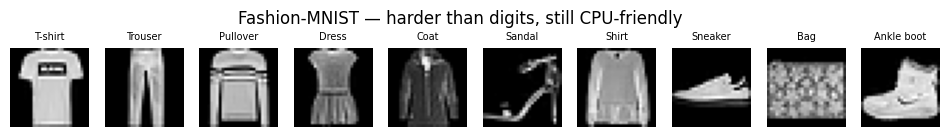

In [5]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import warnings; warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

torch.manual_seed(0); np.random.seed(0)

CLASSES = ["T-shirt","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]
tr = torchvision.datasets.FashionMNIST("data", train=True,  download=True)
te = torchvision.datasets.FashionMNIST("data", train=False, download=True)

N_TRAIN, N_TEST = 10000, 2000
X_train = (tr.data[:N_TRAIN].float() / 255.0).reshape(-1, 784)
y_train = tr.targets[:N_TRAIN].numpy()
X_test  = (te.data[:N_TEST].float() / 255.0).reshape(-1, 784)
y_test  = te.targets[:N_TEST].numpy()
print("Fashion-MNIST:", tuple(X_train.shape), "| classes:", len(CLASSES))

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for c in range(10):
    img = X_train[y_train == c][0].reshape(28, 28)
    axes[c].imshow(img, cmap="gray"); axes[c].set_title(CLASSES[c], fontsize=7); axes[c].axis("off")
plt.suptitle("Fashion-MNIST — harder than digits, still CPU-friendly"); plt.show()


## 2. A shallow autoencoder we can dissect

For the sparse/contractive experiments we use a deliberately **shallow, single-layer** autoencoder:

$$ h = \sigma(W x + b) \quad\text{(the code)}, \qquad \hat{x} = \sigma(W' h + b') $$

Two reasons for keeping it shallow: 
- (1) each of the 100 code units has a **784-weight receptive field
we can reshape to 28×28 and look at** (its "filter"); 
- (2) the contractive Jacobian has a clean closed
form. The code size (100) is smaller than 784 here, but the *penalties* — not the size — will do the
shaping.

**Why `sigmoid` after the encoding (and not ReLU)?** Notice the encoder uses a **sigmoid**, unlike the
denoising conv-AE in nb 02 which used ReLU everywhere except the output. That is deliberate: here the
code activation *is the object we penalize*, and both penalties in this notebook only behave well on a
**bounded, smooth, saturating** nonlinearity.

- **Sparsity needs a bounded code.** With sigmoid every unit sits in $(0,1)$, so "active vs silent" is
  well-defined and comparable across units — the `>0.1 = active` count and the mean-activation numbers
  in §3 only make sense because activations live in a fixed $[0,1]$ box. With unbounded ReLU the L1
  penalty $\lVert h\rVert_1$ is also *cheatable*: the net can shrink activations by scaling $W$ down and
  $W'$ up, lowering the penalty without ever turning units off. Sigmoid **saturates**, so getting the
  penalty down forces genuine sparsity.
- **The contractive penalty only has a closed form for sigmoid.** For $h=\sigma(Wx+b)$,
  $\partial h_j/\partial x = h_j(1-h_j)\,W_j$, so
  $\lVert \partial h/\partial x\rVert_F^2 = \sum_j [h_j(1-h_j)]^2\,\lVert W_j\rVert^2$ — cheap and
  differentiable (exactly the line used in the training loop below). ReLU's derivative is a step (0 or
  1) with zero gradient almost everywhere, so there is nothing smooth to "contract."

This is also the *historically classic* choice: Ng's original sparse autoencoder defined sparsity as a
**KL term** (explained in the primer at the end of §1) pushing each unit's **average** activation
$\hat\rho_j$ toward a small target $\rho$, which only makes sense when $\hat\rho_j\in(0,1)$. We use a
simpler L1 here but keep sigmoid to stay in that same well-behaved regime.


In [6]:
class ShallowAE(nn.Module):
    """h = sigmoid(W x + b);  x_hat = sigmoid(W2 h + b2).  Exposes the code and encoder weight."""
    def __init__(self, d=784, code=100):
        super().__init__()
        self.enc = nn.Linear(d, code)
        self.dec = nn.Linear(code, d)
    def encode(self, x):
        return torch.sigmoid(self.enc(x))
    def forward(self, x):
        h = self.encode(x)
        x_hat = torch.sigmoid(self.dec(h))
        return x_hat, h

def train_ae(mode="plain", lam=0.0, epochs=25, code=100, seed=0):
    """Train a ShallowAE. mode in {plain, sparse, contractive}."""
    torch.manual_seed(seed)
    net = ShallowAE(code=code)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    n = len(X_train)
    for ep in range(epochs):
        perm = torch.randperm(n)
        for i in range(0, n, 128):
            xb = X_train[perm[i:i+128]]
            x_hat, h = net(xb)
            loss = ((x_hat - xb) ** 2).mean()                     # reconstruction
            if mode == "sparse":
                loss = loss + lam * h.abs().mean()                # L1 on code activations
            elif mode == "contractive":
                # ||dh/dx||_F^2 has closed form for h=sigmoid(Wx+b):
                #   sum_j [h_j(1-h_j)]^2 * ||W_j||^2   (per sample), averaged over the batch
                W = net.enc.weight                                # (code, 784)
                dh = (h * (1 - h)) ** 2                           # (B, code)
                w_sq = (W ** 2).sum(dim=1)                        # (code,)
                loss = loss + lam * (dh * w_sq).sum(dim=1).mean()
            opt.zero_grad(); loss.backward(); opt.step()
    return net

print("training plain / sparse / contractive shallow AEs ...")
ae_plain  = train_ae("plain")
ae_sparse = train_ae("sparse", lam=0.05)
ae_contr  = train_ae("contractive", lam=0.2)
print("done.")


training plain / sparse / contractive shallow AEs ...
done.


## 3. Sparse autoencoder — few units fire per input

**Idea.** Penalize the code's activations so that, for any given input, **only a handful of the 100
units light up**. This is a form of *lifetime/population sparsity*: each unit becomes a specialised
detector for a specific pattern (a stroke, a texture, a part), rather than every unit contributing a
little to everything. Sparsity buys **interpretability** and often **better-disentangled** features.

Let's measure sparsity two ways and compare plain vs sparse.


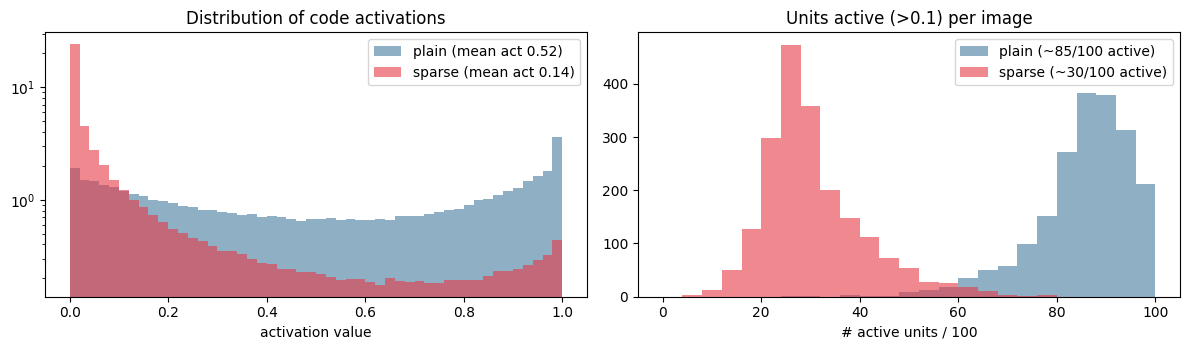

plain : 85/100 units active per image, mean activation 0.518
sparse: 30/100 units active per image, mean activation 0.144


In [7]:
ae_plain.eval(); ae_sparse.eval()
with torch.no_grad():
    _, h_plain  = ae_plain(X_test)
    _, h_sparse = ae_sparse(X_test)
h_plain, h_sparse = h_plain.numpy(), h_sparse.numpy()

# (a) distribution of all activations   (b) how many units are "active" (>0.1) per image
active_plain  = (h_plain  > 0.1).sum(1)
active_sparse = (h_sparse > 0.1).sum(1)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(h_plain.ravel(),  bins=50, alpha=0.6, density=True, label=f"plain (mean act {h_plain.mean():.2f})", color="#457b9d")
ax[0].hist(h_sparse.ravel(), bins=50, alpha=0.6, density=True, label=f"sparse (mean act {h_sparse.mean():.2f})", color="#e63946")
ax[0].set_title("Distribution of code activations"); ax[0].set_xlabel("activation value"); ax[0].set_yscale("log"); ax[0].legend()
ax[1].hist(active_plain,  bins=range(0, 101, 4), alpha=0.6, label=f"plain (~{active_plain.mean():.0f}/100 active)", color="#457b9d")
ax[1].hist(active_sparse, bins=range(0, 101, 4), alpha=0.6, label=f"sparse (~{active_sparse.mean():.0f}/100 active)", color="#e63946")
ax[1].set_title("Units active (>0.1) per image"); ax[1].set_xlabel("# active units / 100"); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"plain : {active_plain.mean():.0f}/100 units active per image, mean activation {h_plain.mean():.3f}")
print(f"sparse: {active_sparse.mean():.0f}/100 units active per image, mean activation {h_sparse.mean():.3f}")


### Look at the learned filters

Each code unit's encoder weights form a 784-vector we can reshape to **28×28** — the pattern that
excites that unit. Compare the plain AE's filters (often global, entangled) with the sparse AE's
(more localised, part-like). This is the classic "the network learned edge/part detectors" picture.


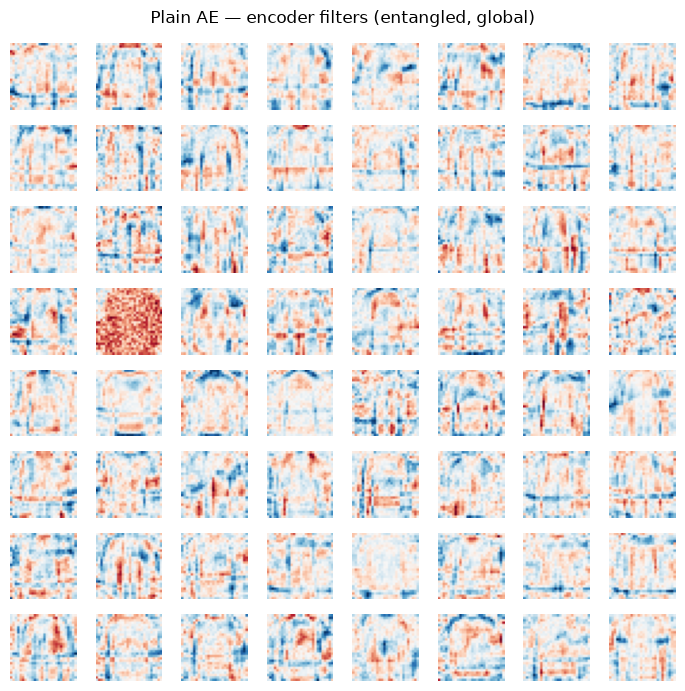

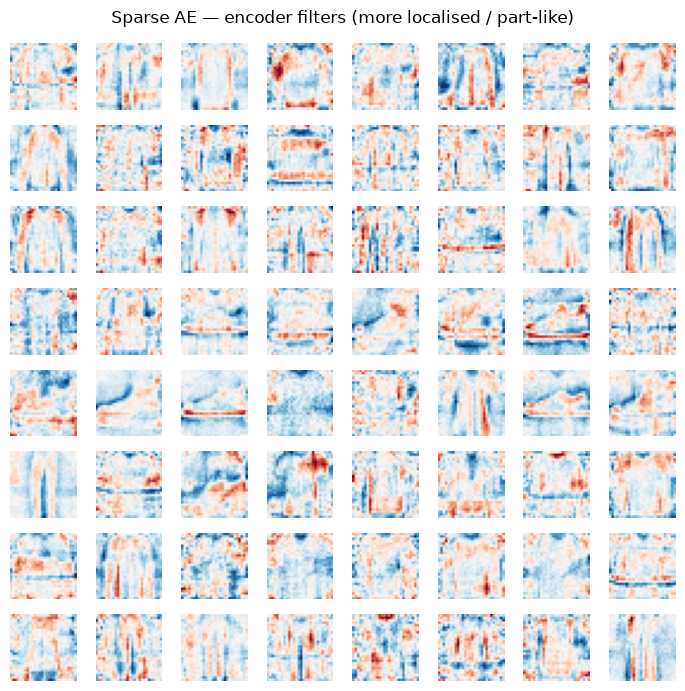

In [4]:
def show_filters(net, title, n=64):
    W = net.enc.weight.detach().numpy()          # (code, 784)
    fig, axes = plt.subplots(8, 8, figsize=(7, 7))
    for k, ax in enumerate(axes.ravel()):
        if k < len(W):
            f = W[k].reshape(28, 28)
            ax.imshow(f, cmap="RdBu_r", vmin=-np.abs(f).max(), vmax=np.abs(f).max())
        ax.axis("off")
    fig.suptitle(title, fontsize=12); plt.tight_layout(); plt.show()

show_filters(ae_plain,  "Plain AE — encoder filters (entangled, global)")
show_filters(ae_sparse, "Sparse AE — encoder filters (more localised / part-like)")


## 4. Contractive autoencoder — a code that doesn't flinch

**Idea.** A good representation should be **stable**: nudging the input a little (noise, a 1-pixel
shift, a lighting change) should barely move the code. The **contractive** penalty enforces exactly
that by penalizing the **Frobenius norm of the encoder's Jacobian** $\partial h/\partial x$ — the
matrix of "how much each code unit changes per unit change of each input pixel".

The effect: the encoder becomes **locally flat** in unimportant directions (contracts them away) and
only responds to the directions that actually matter for reconstruction — i.e. movements **along the
data manifold**. Let's *measure* the robustness directly: perturb test inputs with small noise and
see how much the code moves, plain vs contractive.


code sensitivity  ||Δh||  (lower = more robust):
  plain AE       : 0.706   (recon MSE 0.0146)
  contractive AE : 0.045   (recon MSE 0.0415)   -> 15.9x more robust


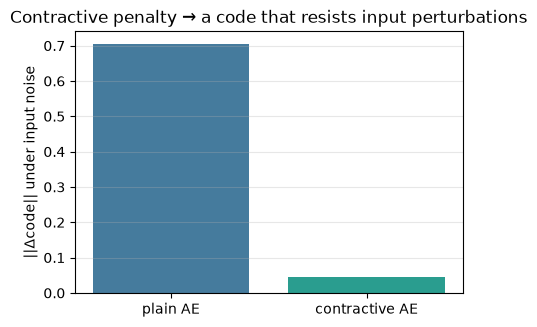

In [5]:
def code_sensitivity(net, sigma=0.1, trials=5):
    """Average ||h(x+noise) - h(x)|| over the test set — lower = more robust code."""
    net.eval()
    with torch.no_grad():
        h0 = net.encode(X_test)
        deltas = []
        for _ in range(trials):
            xp = (X_test + sigma * torch.randn_like(X_test)).clamp(0, 1)
            hp = net.encode(xp)
            deltas.append((hp - h0).norm(dim=1).mean().item())
    return float(np.mean(deltas))

s_plain = code_sensitivity(ae_plain)
s_contr = code_sensitivity(ae_contr)
# reconstruction quality (so we can show robustness didn't destroy usefulness)
with torch.no_grad():
    r_plain = ((ae_plain(X_test)[0] - X_test) ** 2).mean().item()
    r_contr = ((ae_contr(X_test)[0] - X_test) ** 2).mean().item()

print(f"code sensitivity  ||Δh||  (lower = more robust):")
print(f"  plain AE       : {s_plain:.3f}   (recon MSE {r_plain:.4f})")
print(f"  contractive AE : {s_contr:.3f}   (recon MSE {r_contr:.4f})   -> {s_plain/s_contr:.1f}x more robust")

plt.figure(figsize=(5, 3.4))
plt.bar(["plain AE", "contractive AE"], [s_plain, s_contr], color=["#457b9d", "#2a9d8f"])
plt.ylabel("||Δcode|| under input noise"); plt.title("Contractive penalty → a code that resists input perturbations")
plt.grid(alpha=0.3, axis="y"); plt.show()


> **Sparse vs contractive — the one-liner.** Sparse says *"few units on"* (about **which** units
fire); contractive says *"units barely move"* (about **how sensitive** the code is). 

**Very important take away:**

Denoising (nb 02) achieves a similar robustness *implicitly* by corrupting inputs; contractive does it *explicitly* via
the Jacobian. All three are ways of telling the AE: *ignore the unimportant directions.*


## 5. Representation learning — using the code as features

The biggest practical use of autoencoders is **unsupervised feature learning**: train an AE on lots
of **unlabeled** data, then feed its code to a small supervised model. This is the "so what?" of
everything above — a code is only useful if it actually **helps a downstream task**.

> **Which model we use here, and why.** The shallow sparse/contractive AEs in §2–§4 were built to be
> *dissected* — small enough to *see* each filter and to get the contractive Jacobian in closed form —
> **not** to be strong compressors (their code is 100-D, bigger than we need). For a clean test of
> *codes as features* we want a genuinely **compact** code, so below we train a small **denoising** AE
> (784→128→32) — itself another regularized AE (nb 02). The "codes as features" lesson is general; and
> in the **robustness test** we'll bring the **§4 contractive code back**, so its robustness pays off
> downstream instead of ending at §4.

We use that denoising AE plus a linear classifier (logistic regression), asking two questions:

1. **Compression:** how does a 32-D AE code compare to the raw 784 pixels (and to PCA-32)?
2. **Robustness:** if the world gets noisier at test time, which representation holds up — raw pixels,
   the denoising code, or the **contractive** code from §4?


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

class DeepAE(nn.Module):
    def __init__(self, d=784, h=128, z=32):
        super().__init__()
        self.enc = nn.Sequential(nn.Linear(d, h), nn.ReLU(), nn.Linear(h, z))
        self.dec = nn.Sequential(nn.Linear(z, h), nn.ReLU(), nn.Linear(h, d), nn.Sigmoid())
    def forward(self, x):
        z = self.enc(x); return self.dec(z), z

NOISE = 0.35
def add_noise(x): return (x + NOISE * torch.randn_like(x)).clamp(0, 1)

torch.manual_seed(0)
dae = DeepAE(); 
opt = torch.optim.Adam(dae.parameters(), lr=1e-3)
for ep in range(20):                                   # train UNSUPERVISED (labels never used)
    perm = torch.randperm(len(X_train))
    for i in range(0, len(X_train), 128):
        xb = X_train[perm[i:i+128]]
        out, _ = dae(add_noise(xb)); loss = ((out - xb) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
dae.eval()
with torch.no_grad():
    Z_train = dae.enc(X_train).numpy()
    Z_test  = dae.enc(X_test).numpy()
print("trained a 32-D denoising representation on unlabeled data.")


trained a 32-D denoising representation on unlabeled data.


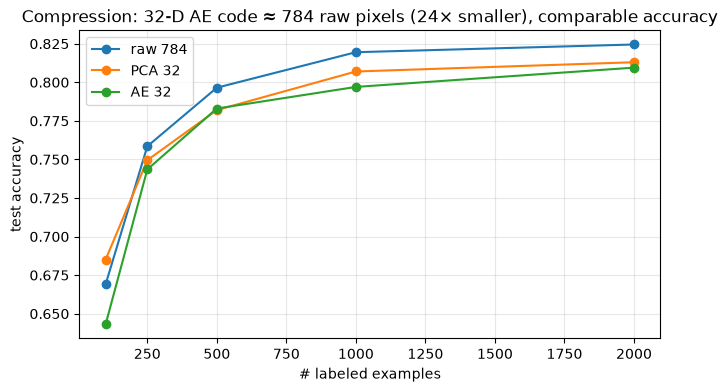

raw 784 : 0.669 0.758 0.796 0.820 0.825
PCA 32  : 0.685 0.750 0.782 0.807 0.813
AE 32   : 0.643 0.744 0.783 0.797 0.809


In [7]:
# --- Q1: compression -- accuracy vs #labels, for raw-784 / PCA-32 / AE-32 ---
pca = PCA(n_components=32).fit(X_train.numpy())
P_train, P_test = pca.transform(X_train.numpy()), pca.transform(X_test.numpy())

budgets = [100, 250, 500, 1000, 2000]
res = {"raw 784": [], "PCA 32": [], "AE 32": []}
for nl in budgets:
    idx = np.random.RandomState(0).choice(len(X_train), nl, replace=False)
    for name, (Ftr, Fte) in {"raw 784": (X_train.numpy(), X_test.numpy()),
                              "PCA 32": (P_train, P_test),
                              "AE 32": (Z_train, Z_test)}.items():
        clf = LogisticRegression(max_iter=300).fit(Ftr[idx], y_train[idx])
        res[name].append(accuracy_score(y_test, clf.predict(Fte)))

plt.figure(figsize=(7.5, 4))
for name, accs in res.items():
    plt.plot(budgets, accs, "o-", label=name)
plt.xlabel("# labeled examples"); plt.ylabel("test accuracy")
plt.title("Compression: 32-D AE code ≈ 784 raw pixels (24× smaller), comparable accuracy")
plt.legend(); plt.grid(alpha=0.3); plt.show()
for name, accs in res.items():
    print(f"{name:8s}:", " ".join(f"{a:.3f}" for a in accs))


In [ ]:
# --- Q2: robustness -- train on CLEAN, evaluate on NOISY (a distribution shift at test time) ---
torch.manual_seed(5)
X_test_noisy = add_noise(X_test)
with torch.no_grad():
    Z_test_noisy = dae.enc(X_test_noisy).numpy()
    # bring the §4 CONTRACTIVE code back: its robustness should now pay off downstream
    C_train      = ae_contr.encode(X_train).numpy()
    C_test       = ae_contr.encode(X_test).numpy()
    C_test_noisy = ae_contr.encode(X_test_noisy).numpy()

clf_raw   = LogisticRegression(max_iter=300).fit(X_train.numpy(), y_train)
clf_ae    = LogisticRegression(max_iter=300).fit(Z_train, y_train)
clf_contr = LogisticRegression(max_iter=300).fit(C_train, y_train)

raw_clean,   raw_noisy   = accuracy_score(y_test, clf_raw.predict(X_test.numpy())),  accuracy_score(y_test, clf_raw.predict(X_test_noisy.numpy()))
ae_clean,    ae_noisy    = accuracy_score(y_test, clf_ae.predict(Z_test)),           accuracy_score(y_test, clf_ae.predict(Z_test_noisy))
contr_clean, contr_noisy = accuracy_score(y_test, clf_contr.predict(C_test)),        accuracy_score(y_test, clf_contr.predict(C_test_noisy))

print(f"                        clean   noisy    drop")
print(f"raw 784 pixels        : {raw_clean:.3f}   {raw_noisy:.3f}   {raw_clean-raw_noisy:.3f}")
print(f"denoising AE 32 code  : {ae_clean:.3f}   {ae_noisy:.3f}   {ae_clean-ae_noisy:.3f}   <- degrades LESS")
print(f"contractive 100 (§4)  : {contr_clean:.3f}   {contr_noisy:.3f}   {contr_clean-contr_noisy:.3f}   <- §4's robust code, tested downstream")

labels = ["raw 784", "denoising AE 32", "contractive 100 (§4)"]
x = np.arange(len(labels))
plt.figure(figsize=(7.5, 3.8))
plt.bar(x - 0.2, [raw_clean, ae_clean, contr_clean], width=0.4, label="clean test", color="#a8dadc")
plt.bar(x + 0.2, [raw_noisy, ae_noisy, contr_noisy], width=0.4, label="noisy test", color="#e63946")
plt.xticks(x, labels); plt.ylabel("test accuracy")
plt.title("Robustness under test-time noise: regularized codes degrade less than raw pixels")
plt.legend(); plt.grid(alpha=0.3, axis="y"); plt.show()


### The honest verdict (this is the nuance interviewers probe)

- **Compression is a real win.** A 32-D AE code reaches nearly the same accuracy as 784 raw pixels —
  a **24× smaller** feature vector (faster/cheaper downstream models, storage, a 2-D map for free).
- **Robustness is a real win — and it's exactly what §4 predicted.** Both regularized codes **degrade
  less under test-time noise** than raw pixels; the **§4 contractive code degrades the *least* of
  all**, its "a code that barely moves when the input wiggles" design goal paying off on a genuine
  downstream task. *Honest caveat:* that same contractive code has the **lowest *clean* accuracy** (a
  100-D shallow code built for dissection, not classification), so it buys robustness at the cost of
  peak accuracy — a trade-off worth naming out loud rather than hiding.
- **But AE features do *not* automatically beat raw pixels on clean accuracy.** A plain autoencoder
  optimizes **reconstruction, not class separation**, so it may even lose a little (it spends capacity
  preserving background pixels a classifier would ignore). *Don't over-claim this in an interview.*
- **How to actually get better features:** add structure the task cares about — **denoising / sparsity
  / contraction** (as here), or push to **self-supervised** objectives (contrastive learning, masked
  autoencoders). That lineage — *learn from unlabeled data, fine-tune with few labels* — is exactly
  what powers today's foundation models. The plain reconstruction AE is the historical seed of it.


## 6. Key takeaways & interview soundbites

**The mental model**

- **Regularized AEs** replace "make the bottleneck small" with "add a penalty on the code", so the
  code can be large yet still non-trivial: **sparse** (L1 → few units fire) or **contractive**
  (Jacobian → code insensitive to input wiggles).
- **Sparse** → interpretable, part-like features. **Contractive** → robust, manifold-aligned features.
  **Denoising** (nb 02) gets robustness implicitly by corrupting the input.
- **Representation learning:** AE codes are **compact** and (with denoising/sparsity) **robust**, but
  not automatically more *discriminative* than raw features — reconstruction ≠ classification.

**Sharp answers for an interview**

- *"What's a sparse autoencoder and why use it?"* → Add an L1/KL penalty on the hidden activations so
  each input activates only a few units. You get interpretable, specialised features and can use an
  overcomplete code without collapsing to identity.
- *"What does the contractive penalty do?"* → Penalizes ‖∂h/∂x‖²_F, making the encoder locally
  invariant — the code contracts away directions that don't matter and only follows the data
  manifold. Robust features, closely related to denoising.
- *"Are autoencoder features good for classification?"* → They're **compact and robust**, great when
  labels are scarce, inputs are high-dimensional/noisy, or you need dimensionality reduction. But a
  plain AE optimizes reconstruction, so it won't necessarily beat raw features on accuracy — for that,
  use denoising/sparse objectives or modern self-supervised methods.
- *"How does this connect to modern deep learning?"* → It's the ancestor of self-supervised
  pretraining: learn representations from unlabeled data, then adapt with few labels. Masked
  autoencoders (MAE) are a direct, state-of-the-art descendant.

**Try it yourself**

1. Increase the sparse `lam` — watch fewer units fire and filters get cleaner (too high → underfitting).
2. Grow the shallow code (compare `code=100` vs `code=400`) and confirm the sparse penalty keeps even
   a large code from collapsing to the identity.
3. Raise `NOISE` and re-check the robustness bar chart — the AE's advantage should widen.
